In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import normalize

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

FILE_PATH = '/content/gdrive/MyDrive/RCEL506_Project/Legal_Text_Dataset/legal_text_classification.csv'

df = pd.read_csv(FILE_PATH)
print('Shape:', df.shape)
df.head()

Mounted at /content/gdrive
Shape: (24985, 4)


,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24985 entries, 0 to 24984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       24985 non-null  object
 1   case_outcome  24985 non-null  object
 2   case_title    24985 non-null  object
 3   case_text     24809 non-null  object
dtypes: object(4)
memory usage: 780.9+ KB


In [6]:

print(df['case_outcome'].value_counts())

case_outcome
cited          12110
referred to     4363
applied         2438
followed        2252
considered      1699
Name: count, dtype: int64


#Data Cleaning

In [7]:
# Drop rows with missing case_text
df = df.dropna(subset=['case_text'])

# Keep only the top 5 most common categories
top5 = ['cited', 'referred to', 'applied', 'followed', 'considered']
df = df[df['case_outcome'].isin(top5)]

df = df.reset_index(drop=True)

print('Records after cleaning:', len(df))
print()
print(df['case_outcome'].value_counts())

Records after cleaning: 22862

case_outcome
cited          12110
referred to     4363
applied         2438
followed        2252
considered      1699
Name: count, dtype: int64


#Data Visualization

/tmp/ipykernel_6067/554904199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='Blues_r', ax=axs[0])


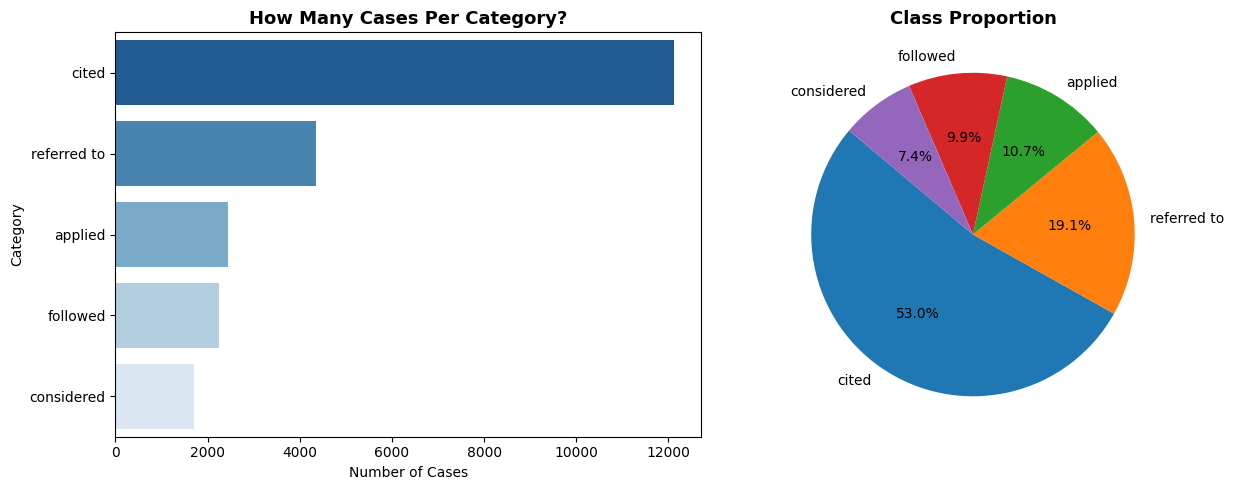

Class imbalance note: cited is 50% of all data.
The naive baseline will exploit this by always predicting cited.


In [10]:
class_counts = df['case_outcome'].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=class_counts.values, y=class_counts.index, palette='Blues_r', ax=axs[0])
axs[0].set_title('How Many Cases Per Category?', fontsize=13, fontweight='bold')
axs[0].set_xlabel('Number of Cases')
axs[0].set_ylabel('Category')

class_counts.plot(kind='pie', autopct='%.1f%%', ax=axs[1], startangle=140)
axs[1].set_ylabel('')
axs[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class imbalance note: cited is 50% of all data.')
print('The naive baseline will exploit this by always predicting cited.')

/tmp/ipykernel_6067/2859683606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='case_outcome', y='word_count', palette='Blues', ax=axs[1])


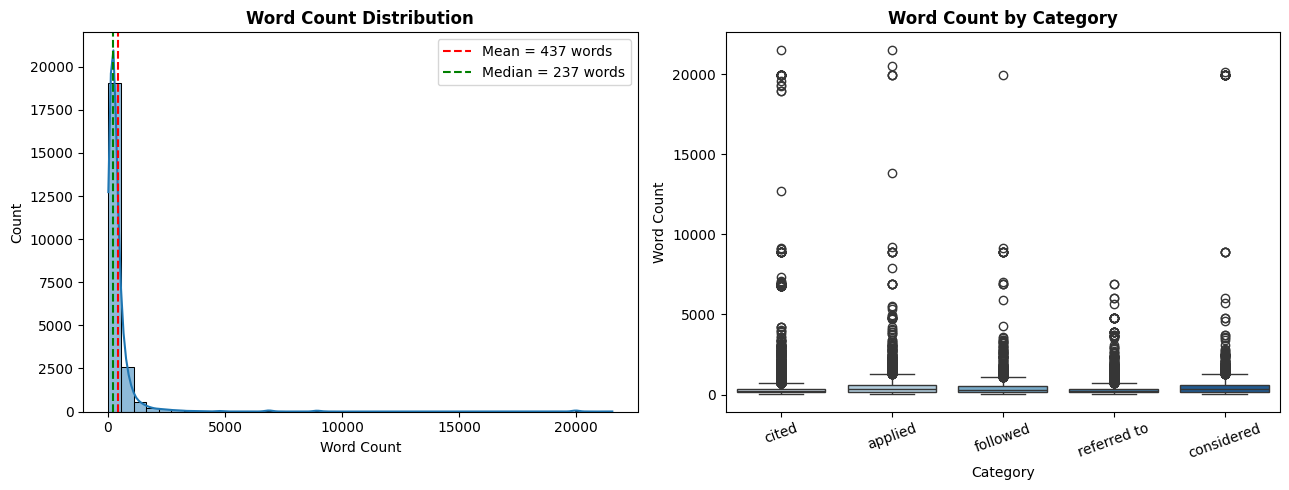

In [11]:
df['word_count'] = df['case_text'].apply(lambda x: len(str(x).split()))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x='word_count', bins=40, kde=True, ax=axs[0])
axs[0].axvline(df['word_count'].mean(),   color='red',   linestyle='--',
               label=f"Mean = {df['word_count'].mean():.0f} words")
axs[0].axvline(df['word_count'].median(), color='green', linestyle='--',
               label=f"Median = {df['word_count'].median():.0f} words")
axs[0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Word Count')
axs[0].legend()

sns.boxplot(data=df, x='case_outcome', y='word_count', palette='Blues', ax=axs[1])
axs[1].set_title('Word Count by Category', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('Word Count')
axs[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#Utilizing TF-IDF Vectorization

TF-IDF is going to work by ranking a each word, each word gets ranked, it it appears in one document but rarely across all documents, it gets a high score. Vice versa, it will get a low score.

I am utilizing max_features=5000 because it only keeps the 5000 most informative words and ignores the rest, stop_words='english automatically removes common words like 'the, is, at, etc', and ngram_range(1,2) looks at single words and two word phrases

In [12]:
# Define the ground truth (in this case X and Y)
X_raw = df['case_text'].astype(str)
y     = df['case_outcome']

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X     = tfidf.fit_transform(X_raw)

# Store feature names for use in the top-words chart later
feature_names = np.array(tfidf.get_feature_names_out())

print('Feature matrix shape:', X.shape)
print(f'{X.shape[0]} documents x {X.shape[1]} word/phrase features')

Feature matrix shape: (22862, 5000)
22862 documents x 5000 word/phrase features


#Training Cells
Training with 80% going to training
20% goes to testing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training set:', X_train.shape[0], 'documents')
print('Testing set: ', X_test.shape[0],  'documents')

Training set: 18289 documents
Testing set:  4573 documents


#Naive Baseline
dumbest model cause it always predicts the most frequent class, which is cited

In [16]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
acc_baseline    = accuracy_score(y_test, y_pred_baseline)


print('NAIVE BASELINE')
print(f'Accuracy: {acc_baseline:.4f}  ({acc_baseline*100:.1f}%)')
print()
print(classification_report(y_test, y_pred_baseline, zero_division=0))

NAIVE BASELINE
Accuracy: 0.5296  (53.0%)

              precision    recall  f1-score   support

     applied       0.00      0.00      0.00       488
       cited       0.53      1.00      0.69      2422
  considered       0.00      0.00      0.00       340
    followed       0.00      0.00      0.00       450
 referred to       0.00      0.00      0.00       873

    accuracy                           0.53      4573
   macro avg       0.11      0.20      0.14      4573
weighted avg       0.28      0.53      0.37      4573



#Naive Baseline Confusion Matrix

everything is being counted as cited

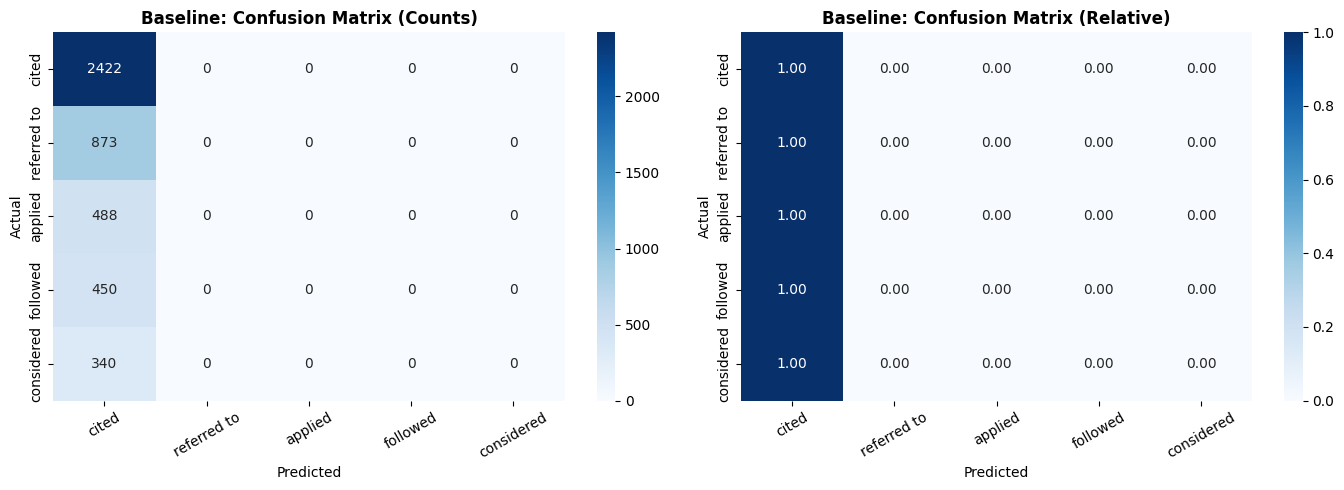

In [17]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=top5)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_baseline, cmap='Blues', annot=True, fmt='g', ax=axs[0],
            xticklabels=top5, yticklabels=top5)
axs[0].set_title('Baseline: Confusion Matrix (Counts)', fontweight='bold')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].tick_params(axis='x', rotation=30)

sns.heatmap(normalize(cm_baseline, norm='l1'), cmap='Blues', annot=True, fmt='.2f', ax=axs[1],
            xticklabels=top5, yticklabels=top5)
axs[1].set_title('Baseline: Confusion Matrix (Relative)', fontweight='bold')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#Logistic Regression
This assigns a coefficient(weight) to every word in the document

In [18]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred)


print('Logistic Regression')
print(f'Training Accuracy: {clf.score(X_train, y_train):.4f}')
print(f'Test Accuracy:     {acc_lr:.4f}  ({acc_lr*100:.1f}%)')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
Training Accuracy: 0.6557
Test Accuracy:     0.5731  (57.3%)

              precision    recall  f1-score   support

     applied       0.39      0.10      0.16       488
       cited       0.59      0.92      0.72      2422
  considered       0.38      0.07      0.12       340
    followed       0.52      0.14      0.22       450
 referred to       0.53      0.28      0.37       873

    accuracy                           0.57      4573
   macro avg       0.48      0.30      0.32      4573
weighted avg       0.53      0.57      0.50      4573



#Logistic Regression Confusion Matrix
There seems to actually be a model reading texts,not just shoving all predictings into cited

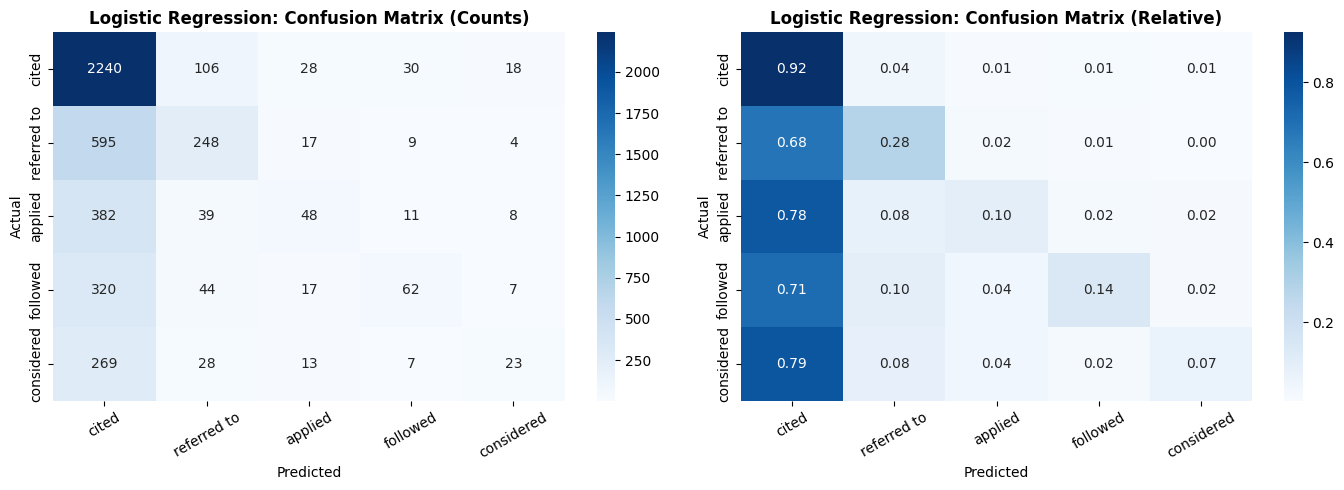

In [19]:
cm_lr = confusion_matrix(y_test, y_pred, labels=top5)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lr, cmap='Blues', annot=True, fmt='g', ax=axs[0],
            xticklabels=top5, yticklabels=top5)
axs[0].set_title('Logistic Regression: Confusion Matrix (Counts)', fontweight='bold')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].tick_params(axis='x', rotation=30)

sns.heatmap(normalize(cm_lr, norm='l1'), cmap='Blues', annot=True, fmt='.2f', ax=axs[1],
            xticklabels=top5, yticklabels=top5)
axs[1].set_title('Logistic Regression: Confusion Matrix (Relative)', fontweight='bold')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6067/2038163161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_idx], y=feature_names[top_idx],
/tmp/ipykernel_6067/2038163161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_idx], y=feature_names[top_idx],
/tmp/ipykernel_6067/2038163161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_idx], y=feature_names[top_idx],
/tmp/ipykernel_6067/2038163161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable 

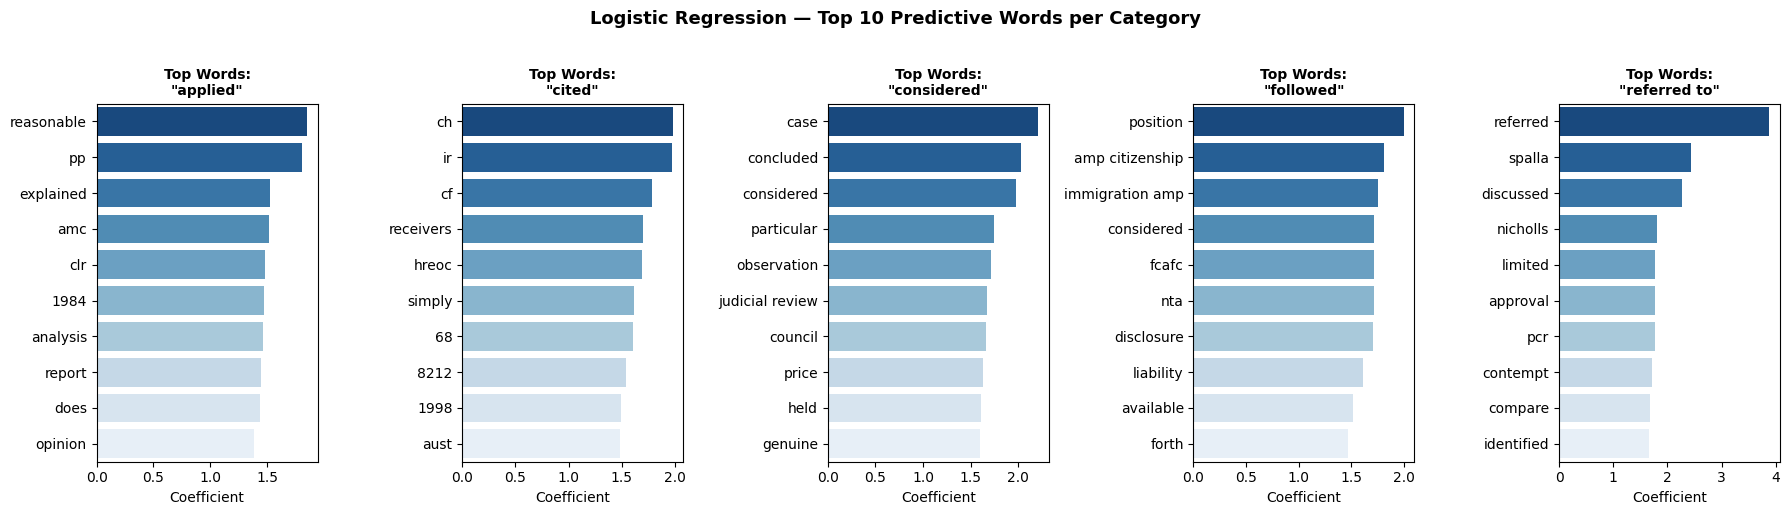

In [20]:
n_top = 10

fig, axs = plt.subplots(1, len(top5), figsize=(18, 5))

for i, cls in enumerate(clf.classes_):
    coefs   = clf.coef_[i]
    top_idx = np.argsort(coefs)[-n_top:][::-1]

    sns.barplot(x=coefs[top_idx], y=feature_names[top_idx],
                palette='Blues_r', ax=axs[i])
    axs[i].set_title(f'Top Words:\n"{cls}"', fontsize=10, fontweight='bold')
    axs[i].set_xlabel('Coefficient')
    axs[i].set_ylabel('')

plt.suptitle('Logistic Regression — Top 10 Predictive Words per Category',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

#10x Cross Validation


10-Fold Cross Validation — Logistic Regression
       accuracy  precision   recall       f1
count   10.0000    10.0000  10.0000  10.0000
mean     0.5086     0.4236   0.5086   0.4263
std      0.0105     0.0192   0.0105   0.0116
min      0.4943     0.3915   0.4943   0.4093
25%      0.5023     0.4150   0.5023   0.4186
50%      0.5071     0.4211   0.5071   0.4270
75%      0.5151     0.4340   0.5151   0.4335
max      0.5280     0.4578   0.5280   0.4476


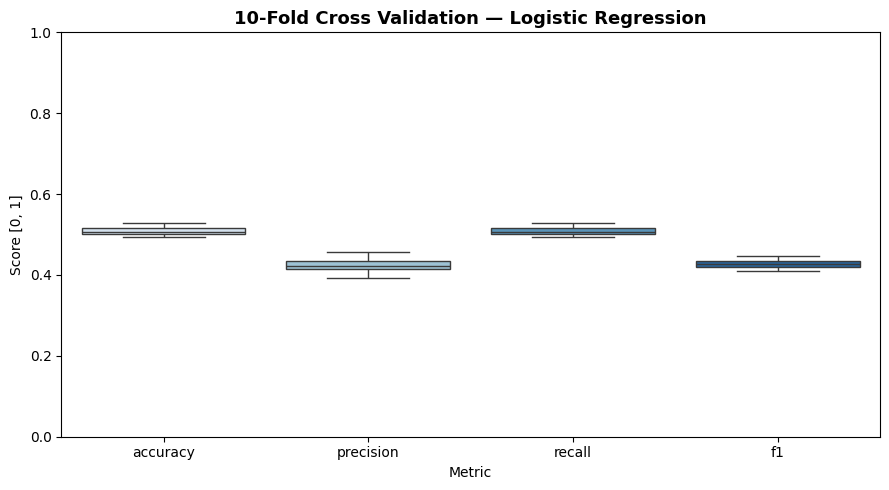

In [21]:
cv_results = cross_validate(
    LogisticRegression(max_iter=1000, random_state=42),
    X, y,
    cv=10,
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs=-1
)

cv_df = pd.DataFrame({
    'accuracy':  cv_results['test_accuracy'],
    'precision': cv_results['test_precision_weighted'],
    'recall':    cv_results['test_recall_weighted'],
    'f1':        cv_results['test_f1_weighted']
})

print('10-Fold Cross Validation — Logistic Regression')
print(cv_df.describe().round(4))

fig, axs = plt.subplots(figsize=(9, 5))
plt.title('10-Fold Cross Validation — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Score [0, 1]')
sns.boxplot(data=cv_df, palette='Blues')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('lr_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

#Random forest

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)


print('RANDOM FOREST')
print(f'Training Accuracy: {rf.score(X_train, y_train):.4f}')
print(f'Test Accuracy:     {acc_rf:.4f}  ({acc_rf*100:.1f}%)')
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

RANDOM FOREST
Training Accuracy: 0.9612
Test Accuracy:     0.6300  (63.0%)

              precision    recall  f1-score   support

     applied       0.62      0.16      0.26       488
       cited       0.61      0.95      0.74      2422
  considered       0.55      0.15      0.24       340
    followed       0.68      0.25      0.37       450
 referred to       0.82      0.37      0.51       873

    accuracy                           0.63      4573
   macro avg       0.65      0.38      0.42      4573
weighted avg       0.65      0.63      0.57      4573



#Random Forest Confusion Matrix

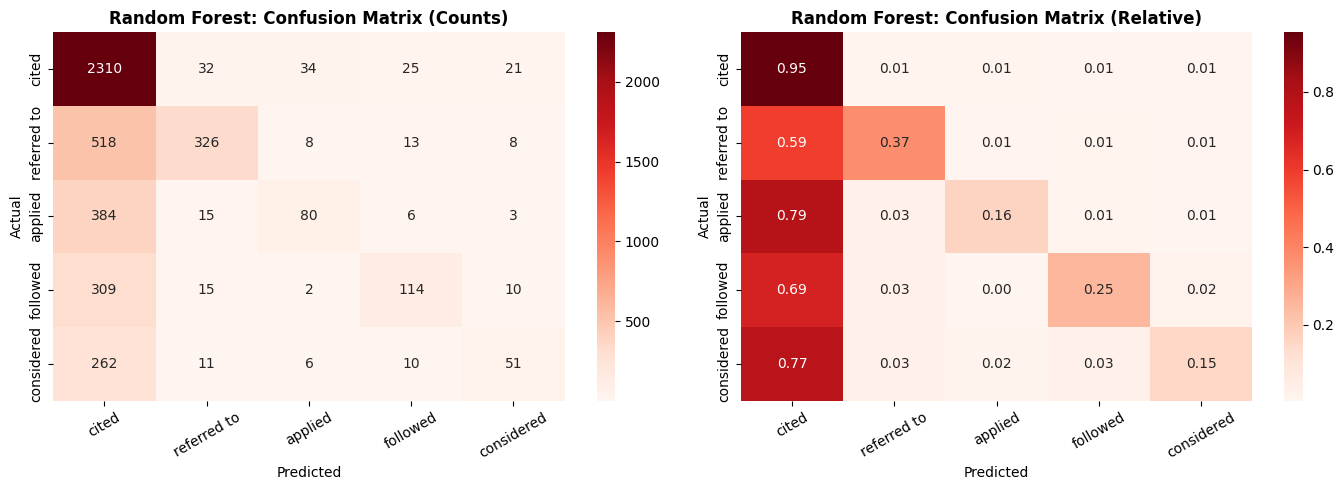

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=top5)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, cmap='Reds', annot=True, fmt='g', ax=axs[0],
            xticklabels=top5, yticklabels=top5)
axs[0].set_title('Random Forest: Confusion Matrix (Counts)', fontweight='bold')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].tick_params(axis='x', rotation=30)

sns.heatmap(normalize(cm_rf, norm='l1'), cmap='Reds', annot=True, fmt='.2f', ax=axs[1],
            xticklabels=top5, yticklabels=top5)
axs[1].set_title('Random Forest: Confusion Matrix (Relative)', fontweight='bold')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

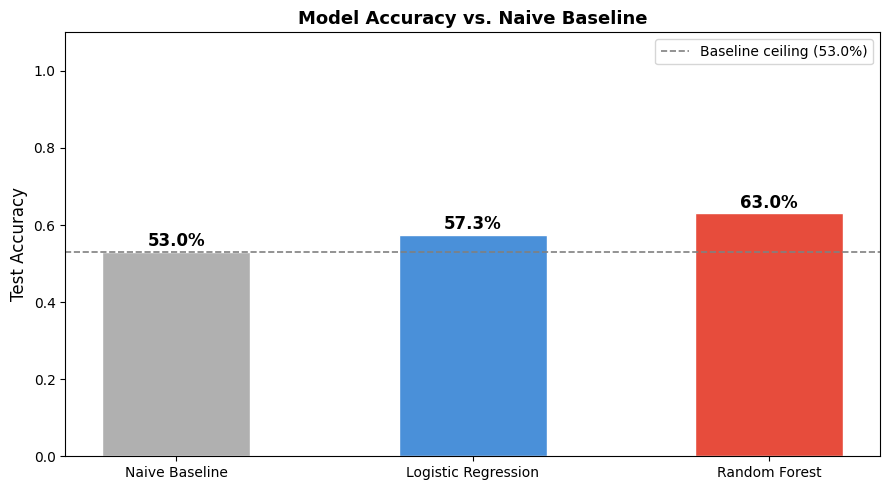

Baseline:             53.0%
Logistic Regression:  57.3%
Random Forest:        63.0%
Improvement:          +10.0 percentage points


In [24]:
models = ['Naive Baseline', 'Logistic Regression', 'Random Forest']
accs   = [acc_baseline, acc_lr, acc_rf]
colors = ['#B0B0B0', '#4A90D9', '#E74C3C']

fig, axs = plt.subplots(figsize=(9, 5))
bars = axs.bar(models, accs, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, accs):
    axs.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val*100:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

axs.axhline(acc_baseline, color='gray', linestyle='--', linewidth=1.2,
            label=f'Baseline ceiling ({acc_baseline*100:.1f}%)')
axs.set_ylim(0, 1.1)
axs.set_ylabel('Test Accuracy', fontsize=12)
axs.set_title('Model Accuracy vs. Naive Baseline', fontsize=13, fontweight='bold')
axs.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline:             {acc_baseline*100:.1f}%')
print(f'Logistic Regression:  {acc_lr*100:.1f}%')
print(f'Random Forest:        {acc_rf*100:.1f}%')
print(f'Improvement:          +{(max(acc_lr, acc_rf) - acc_baseline)*100:.1f} percentage points')

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
